# Dense neural net tutorial for a tabular dataset

This notebook demonstrates how to apply a dense neural network to a tabular dataset. We will load and explore a sample dataset (the [Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) from scikit‑learn), preprocess the data, build a neural network model using dense layers (including non‑linear activation functions), discuss architecture choices, and introduce regularization methods to manage overfitting.

Import the necessary libraries for data handling, visualization, preprocessing, and building the neural network with TensorFlow/Keras.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers, callbacks


In [2]:
def build_dense_model(input_dim, dropout_rate=0.3, l2_reg=1e-4):
    model = models.Sequential()

    # Input layer and first hidden layer with ReLU activation.
    model.add(layers.Dense(64, activation='relu',
                           input_shape=(input_dim,),
                           kernel_regularizer=regularizers.l2(l2_reg)))
    
    model.add(layers.Dropout(dropout_rate))     # Dropout helps combat overfitting by randomly dropping units during training.
    
    # Second hidden layer
    model.add(layers.Dense(32, activation='relu',
                           kernel_regularizer=regularizers.l2(l2_reg)))
    model.add(layers.Dropout(dropout_rate))
    
    # Third hidden layer
    model.add(layers.Dense(16, activation='relu',
                           kernel_regularizer=regularizers.l2(l2_reg)))
    
    model.add(layers.Dense(1, activation='sigmoid'))     # Output layer with sigmoid activation for binary classification

    return model

In [3]:
# Using the same seed will generate the same sequence of random numbers every time you run the code, 
# which is useful for debugging and ensuring consistent results across different runs.
np.random.seed(42)
tf.random.set_seed(42)

Load the tabular Breast Cancer dataset from scikit‑learn, convert it into a Pandas DataFrame, and display basic information to understand its structure and contents.

In [6]:
data = load_breast_cancer()
X = data.data    # feature matrix
y = data.target  # labels (0 = malignant, 1 = benign)

df = pd.DataFrame(X, columns=data.feature_names) # Create a DataFrame for easier exploration
df['target'] = y

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [7]:
print("\nClass Distribution:")
print(df['target'].value_counts())


Class Distribution:
1    357
0    212
Name: target, dtype: int64


Preprocess the data by splitting it into training and testing sets, and standardize the feature values. Proper scaling is essential for deep learning models to converge effectively.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # the stratify=y argument in the train_test_split function ensures that the distribution of labels in 
                                                     # the target variable y is preserved in both the training and test sets. 
)

# Standardize the feature data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Preprocessing complete. Training samples:", X_train_scaled.shape[0])


Preprocessing complete. Training samples: 455


Remarks on standard scaling:
- Gradient-based optimization algorithms rely on the gradient of the loss function to update the model’s weights. 
    When features have widely varying scales, the gradient may point in very different directions for different features. This can cause the optimizer to "zigzag" and take longer to converge, especially if the features are on very different scales. Standard scaling helps to make the gradient more uniform, which allows the optimizer to converge faster and more efficiently.
- If the features have large disparities in scale, some weights might be updated much more than others because the learning rate could be too high for certain features.
- By standardizing the data, the input values are centered around 0, which keeps them in a more effective range for many activation functions, improving learning dynamics.
- For some neural network architectures, especially with weight initialization techniques (like Xavier or He initialization), it's easier to choose appropriate weight initialization schemes if the data is standardized. This ensures the gradients are neither too small nor too large, which helps avoid issues like vanishing or exploding gradients.
- When the inputs have vastly different scales, this can cause issues in numerical computations and result in poor performance or even errors due to precision limitations.


Build a dense neural network model using Keras. 

In [29]:
model = build_dense_model(input_dim=X_train_scaled.shape[1])

model.summary() # Display the architecture of the model

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 64)                1984      
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_9 (Dense)             (None, 32)                2080      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                                                 
 dense_11 (Dense)            (None, 1)                 17        
                                                                 
Total params: 4609 (18.00 KB)
Trainable params: 4609 (

Compile the model with an appropriate loss function and optimizer. For binary classification we can use binary cross‑entropy as the loss and monitor the accuracy during training. An early stopping callback is configured to prevent overfitting if the validation loss stops improving.

In [30]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Define an early stopping callback to halt training when validation loss does not improve
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10, # specifies how many epochs the training process should continue without improvement in the monitored metric 
    restore_best_weights=True # this option ensures that the model's weights are restored to the best weights observed during training
)

Train the model. We reserve 20% of the training data as a validation set. This cell also visualizes the training progress, indicating how the loss and accuracy evolve over epochs. Monitoring these curves can flag potential overfitting or underfitting.

In [31]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/100
12/12 - 2s - loss: 0.6159 - accuracy: 0.6593 - val_loss: 0.5304 - val_accuracy: 0.6593 - 2s/epoch - 126ms/step
Epoch 2/100
12/12 - 0s - loss: 0.4528 - accuracy: 0.7637 - val_loss: 0.4185 - val_accuracy: 0.9231 - 73ms/epoch - 6ms/step
Epoch 3/100
12/12 - 0s - loss: 0.3619 - accuracy: 0.8791 - val_loss: 0.3269 - val_accuracy: 0.9451 - 91ms/epoch - 8ms/step
Epoch 4/100
12/12 - 0s - loss: 0.2935 - accuracy: 0.9093 - val_loss: 0.2504 - val_accuracy: 0.9451 - 77ms/epoch - 6ms/step
Epoch 5/100
12/12 - 0s - loss: 0.2249 - accuracy: 0.9341 - val_loss: 0.1933 - val_accuracy: 0.9451 - 240ms/epoch - 20ms/step
Epoch 6/100
12/12 - 0s - loss: 0.1891 - accuracy: 0.9588 - val_loss: 0.1541 - val_accuracy: 0.9451 - 88ms/epoch - 7ms/step
Epoch 7/100
12/12 - 0s - loss: 0.1479 - accuracy: 0.9615 - val_loss: 0.1280 - val_accuracy: 0.9670 - 77ms/epoch - 6ms/step
Epoch 8/100
12/12 - 0s - loss: 0.1407 - accuracy: 0.9505 - val_loss: 0.1111 - val_accuracy: 0.9670 - 81ms/epoch - 7ms/step
Epoch 9/100
12

Visualize the training history by plotting the loss and accuracy curves for both training and validation sets. These plots help in understanding overfitting (if training loss is much lower than validation loss) or underfitting (if both losses are high).

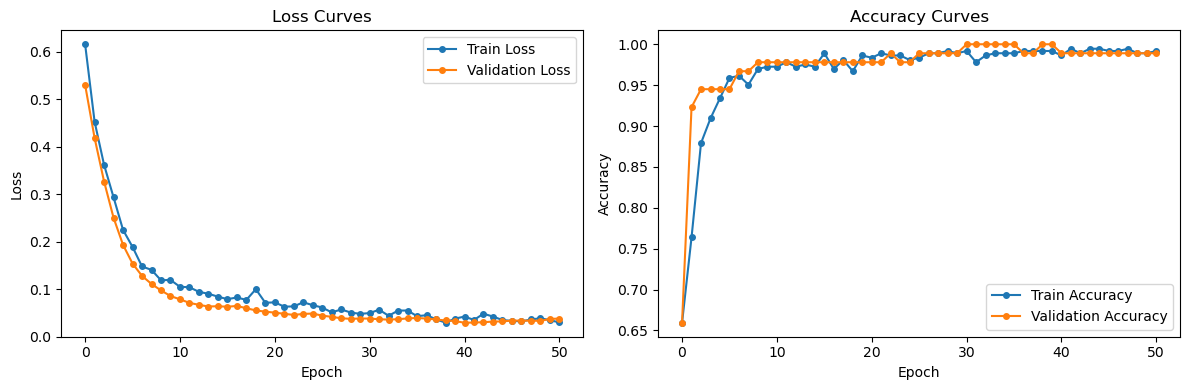

In [32]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', marker='o', markersize=4)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', markersize=4)
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', markersize=4)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', markersize=4)
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Find the epoch where the best validation loss occurred.

In [33]:
best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))

print(f"The best weights were obtained from epoch {best_epoch + 1}")

The best weights were obtained from epoch 41


Evaluate the trained model on the test set to estimate its generalization performance. 

In [34]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1365
Test Accuracy: 0.9474
